# Documented structure defense — OpenView 3D


Defense was observational and targeted. Estimates are therefore reported as matched associations and directional contrasts rather than randomized treatment effects. All outputs are isolated under the OpenView-derived results and S2S-NC figure directories.

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    path for path in [cwd, *cwd.parents]
    if (path / 'data').exists() and (path / 'src').exists()
    and (path / 'notebooks').exists()
)
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import pandas as pd
from IPython.display import Markdown, display

from src.analysis.defense import (
    build_openview_focal_table, build_openview_view_decomposition,
    covariate_balance, direct_effect_table, match_defended,
    mechanism_regression_table, mechanism_table,
    mechanism_partial_damage_table, prepare_spillover_match,
    publication_table_markdown, spillover_table, spillover_stage_table,
)
from src.figure_paths import figure_dir, save_figure
from src.viz.defense import (
    plot_defense_locations, plot_defense_spillover,
    plot_defense_spillover_stages,
)

OPENVIEW_3D_RUN = Path(os.environ.get(
    'OPENVIEW_3D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/lariac6_wui_all_2mi_bvf_3d_nf_cone85_nosolar',
))
DATA = PACKAGE_ROOT / 'data'
DERIVED = DATA / 'derived' / 'openview3d_lariac6_2mi'
ANALYSIS_PATH = DERIVED / 'analysis_openview3d.parquet'
BUILDING_CACHE = DERIVED / 'county_buildings.parquet'
EDGE_CACHE = DERIVED / 'defense_openview3d_directed_edges.parquet'
DESIGN_CACHE = DERIVED / 'defense_design_cache_openview3d'
RESULTS = DERIVED / 'defense'
SOURCE_DATA = RESULTS
# Only the matched-control balance panel is supplementary here.
EXPLORATORY = figure_dir('exploratory')
SUPPLEMENTARY = figure_dir('supplementary')
for directory in [RESULTS, DESIGN_CACHE]:
    directory.mkdir(parents=True, exist_ok=True)
N_BOOT = int(os.environ.get('OPENVIEW_DEFENSE_BOOTSTRAPS', '2000'))
SENSITIVITY_BOOT = int(os.environ.get('OPENVIEW_DEFENSE_SENSITIVITY_BOOTSTRAPS', '1000'))
BOOTSTRAP_SEED = 20250809
SENSITIVITY_SEED = 20250810
REBUILD_EDGES = False

## Directional focal sample

Eligible focal structures have reconstructed arrival times and at least one OpenView-connected neighbor reached on each side of the focal arrival within three hours. Down-fire and up-fire outcomes are calculated among undefended neighbors within 30.48 m (100 ft), using footprint-to-footprint distance from the OpenView geometry cache. The up-fire outcome is a temporal placebo because it was determined before the focal outcome.

In [2]:
focal = build_openview_focal_table(
    PROJECT_ROOT, OPENVIEW_3D_RUN, ANALYSIS_PATH, BUILDING_CACHE, EDGE_CACHE,
    rebuild_edges=REBUILD_EDGES,
)
focal.to_parquet(SOURCE_DATA / 'defense_focal_table_openview3d.parquet', index=False)
focal_summary = pd.DataFrame([
    {'population': 'Eligible focal structures', 'n': len(focal)},
    {'population': 'Documented defended focal structures',
     'n': int(focal.defended.sum())},
])
focal_summary.to_csv(
    RESULTS / 'defense_focal_population_openview3d.csv', index=False,
)
display(focal_summary)
print(f'Directional edge cache: {EDGE_CACHE}')

,population,n
0,Eligible focal structures,24317
1,Documented defended focal structures,1155


Directional edge cache: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/defense_openview3d_directed_edges.parquet


## Within-fire matching and covariate balance

Propensity scores use pre-arrival OpenView coupling, potential total OpenView coupling, destroyed-neighbor count, local building density, wind at arrival, arrival time, elevation, vegetation and fire. Defended structures are matched without replacement to the nearest undefended structure on the propensity-logit scale, exactly within fire, with a 0.2-standard-deviation caliper.

In [3]:
matched, propensity_model = match_defended(focal)
balance = covariate_balance(focal, matched)
matched.to_parquet(SOURCE_DATA / 'defense_matched_sample_openview3d.parquet', index=False)
balance.to_csv(RESULTS / 'tableS_defense_covariate_balance.csv', index=False)
print(f'Matched pairs: {matched.pair_id.nunique():,}')
print(f'Maximum absolute post-match SMD: {balance.smd_after.abs().max():.3f}')
display(balance.round(3))

Matched pairs: 1,154
Maximum absolute post-match SMD: 0.048


,covariate,smd_before,smd_after
0,up_share,-0.214,0.016
1,l_F_upfire_wmean,-0.216,0.045
2,l_F_total_wmean,-0.255,0.016
3,n_destroyed_bldgs,-0.447,0.048
4,l_n_neighbors_500ft,-0.574,0.016
5,wind_speed_arrival_mph,0.395,0.036
6,arrival,0.112,-0.036
7,elevation,-0.166,-0.023
8,ndvi_mean,-0.101,0.016


### Spatial distribution of documented defense

The map shows all documented defended structures in the updated OpenView analysis population and identifies defended targets retained by the primary matched analysis.

,fire,documented_defense_targets,matched_defense_targets,not_retained_after_matching
0,EATON,646,605,41
1,PALISADES,862,549,313


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/exploratory/ED_defense_target_locations.pdf


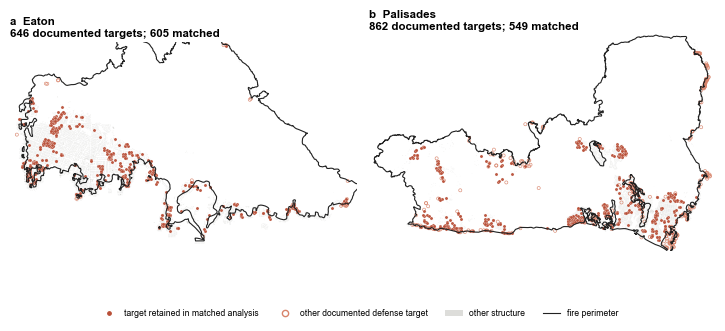

In [4]:
fig, defense_location_summary = plot_defense_locations(
    PROJECT_ROOT, matched, EXPLORATORY,
    analysis_path=ANALYSIS_PATH, building_cache=BUILDING_CACHE,
)
defense_location_summary.to_csv(
    RESULTS / 'tableS_defense_target_locations.csv', index=False,
)
display(defense_location_summary)
print('saved', EXPLORATORY / 'ED_defense_target_locations.pdf')

### Matched controls and covariate balance

The matched-pair map shows defended targets, their paired undefended controls, documented targets not retained after matching, and post-match standardized mean differences for the propensity covariates.

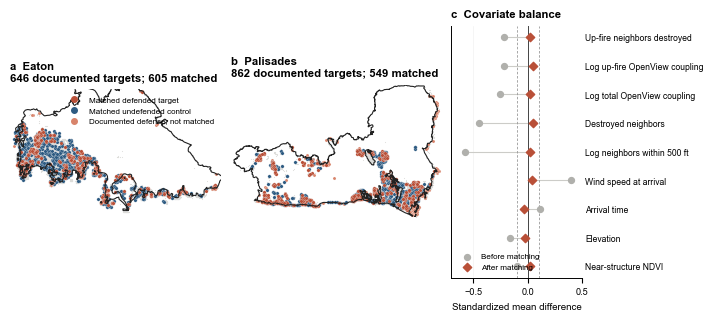

largest |SMD| after matching: 0.048
matched-pair separation: median 9,645 ft
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/supplementary/defense_matched_controls_and_balance.png


In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from src.viz.style import apply_style

FIRES = ['EATON', 'PALISADES']
M_TO_FT = 3.28084
DEFENDED_COLOR = '#B95038'
CONTROL_COLOR = '#2E5B82'
UNMATCHED_COLOR = '#D8846B'

analysis_map = pd.read_parquet(
    ANALYSIS_PATH, columns=['graph_id', 'fire', 'defended'],
)
all_buildings = (
    gpd.read_parquet(BUILDING_CACHE, columns=['building_id', 'geometry'])
    .rename(columns={'building_id': 'graph_id'})
)
perimeters = (gpd.read_parquet(DATA / 'nx' / 'fire_perims.parquet')
              .to_crs(all_buildings.crs).set_index('FIRE_NAME'))
defended_ids = set(
    analysis_map.loc[analysis_map.defended.eq(True), 'graph_id'].astype(int)
)
matched_ids = {
    role: set(matched.loc[matched.defended.eq(flag), 'graph_id'].astype(int))
    for role, flag in [('defended', 1), ('control', 0)]
}
COVARIATE_LABELS = {
    'up_share': 'Up-fire neighbors destroyed',
    'l_F_upfire_wmean': 'Log up-fire OpenView coupling',
    'l_F_total_wmean': 'Log total OpenView coupling',
    'n_destroyed_bldgs': 'Destroyed neighbors',
    'l_n_neighbors_500ft': 'Log neighbors within 500 ft',
    'wind_speed_arrival_mph': 'Wind speed at arrival',
    'arrival': 'Arrival time', 'elevation': 'Elevation',
    'ndvi_mean': 'Near-structure NDVI',
}

apply_style()
fig = plt.figure(figsize=(7.2, 3.55))
grid = fig.add_gridspec(1, 3, width_ratios=[1, 1, .62], wspace=.05)
axes = [fig.add_subplot(grid[0, index]) for index in range(2)]
pair_rows, location_rows = [], []
for panel, (ax, fire_name) in enumerate(zip(axes, FIRES)):
    fire_ids = set(
        analysis_map.loc[analysis_map.fire.eq(fire_name), 'graph_id'].astype(int)
    )
    buildings = all_buildings[
        all_buildings.graph_id.isin(fire_ids)
    ].drop_duplicates('graph_id').copy()
    centres = buildings.geometry.representative_point()
    buildings['x'], buildings['y'] = centres.x.to_numpy(), centres.y.to_numpy()
    role = np.where(
        buildings.graph_id.isin(matched_ids['defended']), 'defended',
        np.where(buildings.graph_id.isin(matched_ids['control']), 'control',
                 np.where(buildings.graph_id.isin(defended_ids),
                          'unmatched', 'other')),
    )
    buildings['role'] = role
    ax.scatter(buildings.x[role == 'other'], buildings.y[role == 'other'],
               s=.6, color='#DDDDDA', linewidths=0, rasterized=True, zorder=1)
    for label, color, size, zorder in [
        ('unmatched', UNMATCHED_COLOR, 5.0, 2),
        ('control', CONTROL_COLOR, 6.0, 3),
        ('defended', DEFENDED_COLOR, 6.0, 4),
    ]:
        block = buildings[buildings.role.eq(label)]
        ax.scatter(block.x, block.y, s=size, color=color,
                   edgecolors='white', linewidths=.15, rasterized=True,
                   zorder=zorder)
        location_rows.append({'fire': fire_name, 'role': label,
                              'structures': int(len(block))})
    coordinates = buildings.set_index('graph_id')[['x', 'y']]
    for pair_id, pair in matched[matched.fire.eq(fire_name)].groupby('pair_id'):
        treated = int(pair.loc[pair.defended.eq(1), 'graph_id'].iloc[0])
        control = int(pair.loc[pair.defended.eq(0), 'graph_id'].iloc[0])
        if treated in coordinates.index and control in coordinates.index:
            separation = float(np.hypot(
                *(coordinates.loc[treated] - coordinates.loc[control])))
            pair_rows.append({'fire': fire_name, 'pair_id': pair_id,
                              'separation_ft': separation * M_TO_FT})
    perimeter = perimeters.loc[fire_name].geometry.boundary
    for part in getattr(perimeter, 'geoms', [perimeter]):
        ax.plot(*part.xy, color='#222222', lw=.8, zorder=5)
    xmin, ymin, xmax, ymax = buildings.total_bounds
    ax.set_xlim(xmin - .015 * (xmax - xmin), xmax + .015 * (xmax - xmin))
    ax.set_ylim(ymin - .015 * (ymax - ymin), ymax + .015 * (ymax - ymin))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    counts = buildings.role.value_counts()
    ax.set_title(
        f'{chr(97 + panel)}  {fire_name.title()}\n'
        f'{counts.get("defended", 0) + counts.get("unmatched", 0):,} '
        f'documented targets; {counts.get("defended", 0):,} matched',
        loc='left', fontsize=8.2, fontweight='bold')

defense_pair_separation = pd.DataFrame(pair_rows)
defense_location_counts = pd.DataFrame(location_rows)
balance_panel = covariate_balance(focal, matched).assign(
    label=lambda frame: frame.covariate.map(COVARIATE_LABELS))
balance_axis = fig.add_subplot(grid[0, 2])
positions = np.arange(len(balance_panel))[::-1]
for column, color, marker, label in [
    ('smd_before', '#B0B0AC', 'o', 'Before matching'),
    ('smd_after', '#B95038', 'D', 'After matching'),
]:
    balance_axis.scatter(balance_panel[column], positions, s=18, color=color,
                         marker=marker, zorder=3, label=label)
balance_axis.hlines(positions, balance_panel.smd_before,
                    balance_panel.smd_after, color='#CCCCC8', lw=.8, zorder=2)
for threshold in (-.1, .1):
    balance_axis.axvline(threshold, color='#999999', lw=.6, ls=(0, (3, 2)))
balance_axis.axvline(0, color='#444444', lw=.7)
balance_axis.yaxis.tick_right()
balance_axis.set_yticks(positions, balance_panel.label, fontsize=6.2)
balance_axis.tick_params(axis='y', length=0, pad=2)
balance_axis.set_xlabel('Standardized mean difference', fontsize=7)
balance_axis.tick_params(axis='x', labelsize=6.6)
balance_axis.set_xlim(-.7, .5)
balance_axis.grid(axis='x', color='#EEEEEE', lw=.4)
balance_axis.spines[['top', 'right']].set_visible(False)
balance_axis.legend(loc='lower left', fontsize=5.8, frameon=False)
balance_axis.set_title('c  Covariate balance', loc='left', fontsize=8.2,
                       fontweight='bold')
axes[0].legend(handles=[
    Line2D([0], [0], marker='o', lw=0, color=DEFENDED_COLOR, markersize=4,
           label='Matched defended target'),
    Line2D([0], [0], marker='o', lw=0, color=CONTROL_COLOR, markersize=4,
           label='Matched undefended control'),
    Line2D([0], [0], marker='o', lw=0, color=UNMATCHED_COLOR, markersize=4,
           label='Documented defense, not matched'),
], loc='upper right', fontsize=5.8, frameon=False)
fig.subplots_adjust(left=.005, right=.80, top=.86, bottom=.15)

defense_pair_separation.to_csv(
    RESULTS / 'tableS_defense_pair_separation.csv', index=False)
defense_location_counts.to_csv(
    RESULTS / 'tableS_defense_location_counts.csv', index=False)
balance_panel.to_csv(RESULTS / 'tableS_defense_balance_panel.csv', index=False)
pair_stem = save_figure(
    fig, 'defense_matched_controls_and_balance', 'supplementary',
    source=balance_panel,
)
plt.show()
print('largest |SMD| after matching: {:.3f}'.format(
    balance_panel.smd_after.abs().max()))
print('matched-pair separation: median {:,.0f} ft'.format(
    defense_pair_separation.separation_ft.median()))
print('saved', pair_stem.with_suffix('.png'))

## Direct matched association

The primary direct estimand is the matched defended-minus-control difference in survival. Confidence intervals resample focal structures within fire. The damage-category table indicates whether lower destruction corresponds to undamaged or partial-damage survival.

In [6]:
direct, outcomes = direct_effect_table(
    matched, n_boot=N_BOOT, seed=BOOTSTRAP_SEED
)
direct.to_csv(RESULTS / 'table2a_defense_direct_effect.csv', index=False)
outcomes.to_csv(RESULTS / 'table2b_defense_outcomes.csv', index=False)
display(direct.round(3))
display(outcomes.round(1))

,sample,matched_pairs,survival_difference_pp,ci_lo,ci_hi,p_value
0,Pooled,1154,13.605,9.591,17.680,0.000
1,Eaton,605,7.438,1.863,12.737,0.004
2,Palisades,549,20.401,14.583,26.231,0.000


outcome3,group,Undamaged,Partial,Destroyed
0,Matched control,39.3,8.1,52.6
1,Defended,35.8,25.2,39.0


### Combined direct-effect and outcome table

The publication table combines outcome distributions with the matched survival contrast for the pooled sample and each fire. Values are reported for matched controls and defended structures, with bootstrap confidence intervals and pair-clustered inference.

In [7]:
def _p_text(value):
    return '<0.001' if value < .001 else f'{value:.3f}'

combined_rows = []
combined_samples = [('Pooled', matched)] + [
    (fire.title(), matched[matched.fire.eq(fire)]) for fire in ('EATON', 'PALISADES')
]
for label, frame in combined_samples:
    shares = (
        frame.groupby('defended').outcome3.value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )
    estimate = direct[direct['sample'].eq(label)].iloc[0]
    combined_rows.append({
        'Sample': label,
        'Matched pairs': int(frame.pair_id.nunique()),
        'Undamaged, %':
            f'{shares.loc[0, "Undamaged"]:.1f} / {shares.loc[1, "Undamaged"]:.1f}',
        'Partial damage, %':
            f'{shares.loc[0, "Partial"]:.1f} / {shares.loc[1, "Partial"]:.1f}',
        'Destroyed, %':
            f'{shares.loc[0, "Destroyed"]:.1f} / {shares.loc[1, "Destroyed"]:.1f}',
        'Survival difference, pp (95% CI)':
            (f'{estimate.survival_difference_pp:.1f} '
             f'({estimate.ci_lo:.1f} to {estimate.ci_hi:.1f})'),
        'P value': _p_text(estimate.p_value),
    })
direct_outcomes_publication = pd.DataFrame(combined_rows)
direct_outcomes_publication.to_csv(
    RESULTS / 'table2ab_defense_direct_outcomes_publication.csv', index=False
)
(RESULTS / 'table2ab_defense_direct_outcomes_publication.html').write_text(
    direct_outcomes_publication.to_html(index=False, border=0)
)
display(
    direct_outcomes_publication.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'),
                                      ('font-weight', 'bold'),
                                      ('white-space', 'normal')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
    ])
)
print('Values are matched control / defended.')
print('saved Word-copyable table:',
      RESULTS / 'table2ab_defense_direct_outcomes_publication.html')

Sample,Matched pairs,"Undamaged, %","Partial damage, %","Destroyed, %","Survival difference, pp (95% CI)",P value
Pooled,1154,39.3 / 35.8,8.1 / 25.2,52.6 / 39.0,13.6 (9.6 to 17.7),<0.001
Eaton,605,48.8 / 36.0,5.3 / 25.5,46.0 / 38.5,7.4 (1.9 to 12.7),0.004
Palisades,549,29.0 / 35.5,11.1 / 25.0,59.9 / 39.5,20.4 (14.6 to 26.2),<0.001


Values are matched control / defended.
saved Word-copyable table: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/defense/table2ab_defense_direct_outcomes_publication.html


## Down-fire spillover

The spillover analysis restricts the focal population to structures for which at least 75% of up-fire neighbors were destroyed and for which outcomes are observed among undefended neighbors within 100 ft in both directions. Defended structures are then rematched within that restricted population. The directional contrast subtracts the up-fire placebo from the down-fire comparison.

In [8]:
iv_eligible, iv_matched, iv_propensity_model = prepare_spillover_match(
    focal, threshold=.75
)
iv_balance = covariate_balance(iv_eligible, iv_matched)
iv_matched.to_parquet(
    SOURCE_DATA / 'defense_spillover_matched_sample_openview3d.parquet', index=False
)
iv_balance.to_csv(
    RESULTS / 'tableS_defense_spillover_covariate_balance.csv', index=False
)
print(f'IV-eligible structures: {len(iv_eligible):,}')
print(f'Complete IV matched pairs: {iv_matched.pair_id.nunique():,}')
print(f'Maximum absolute post-match SMD: {iv_balance.smd_after.abs().max():.3f}')
display(iv_balance.round(3))

spillover, spillover_figure_results, high_exposure = spillover_table(
    iv_matched, n_boot=N_BOOT, seed=BOOTSTRAP_SEED
)
spillover.to_csv(RESULTS / 'table2c_defense_spillover.csv', index=False)
display(spillover.round(3))

IV-eligible structures: 10,663
Complete IV matched pairs: 262
Maximum absolute post-match SMD: 0.096


,covariate,smd_before,smd_after
0,up_share,-0.243,0.096
1,l_F_upfire_wmean,-0.117,0.070
2,l_F_total_wmean,-0.065,0.047
3,n_destroyed_bldgs,-0.444,0.024
4,l_n_neighbors_500ft,-0.438,-0.028
5,wind_speed_arrival_mph,0.225,-0.007
6,arrival,0.025,-0.031
7,elevation,-0.188,-0.006
8,ndvi_mean,-0.186,-0.050


,sample,n,defended_n,first_stage,first_stage_F,downfire_contrast,downfire_contrast_lo,downfire_contrast_hi,upfire_placebo,upfire_placebo_lo,upfire_placebo_hi,directional_contrast,directional_contrast_lo,directional_contrast_hi,local_iv,local_iv_lo,local_iv_hi
0,Pooled,524,262,0.275,54.628,-0.108,-0.169,-0.049,-0.023,-0.063,0.013,-0.085,-0.152,-0.015,-0.308,-0.572,-0.060
1,Eaton,264,132,0.273,26.135,-0.095,-0.171,-0.013,-0.036,-0.096,0.026,-0.060,-0.162,0.041,-0.219,-0.607,0.179
2,Palisades,260,130,0.277,28.433,-0.121,-0.212,-0.031,-0.011,-0.057,0.035,-0.110,-0.200,-0.019,-0.397,-0.785,-0.067


### Spillover publication table

The table reports the focal-survival first stage, down-fire neighbor contrast, up-fire placebo, difference-in-differences, and the directional contrast scaled by the first stage, pooled and by fire.

In [9]:
def _pp(value):
    return f'{100 * value:.1f}'.replace('-', '−')

def _estimate_ci(row, name):
    return (f'{_pp(row[name])} '
            f'({_pp(row[name + "_lo"])} to {_pp(row[name + "_hi"])})')

publication_rows = []
for _, row in spillover.iterrows():
    publication_rows.append({
        'Sample': row['sample'],
        'Matched pairs': int(row['n'] // 2),
        'First stage, pp (F)': 
            f'{_pp(row["first_stage"])} ({row["first_stage_F"]:.1f})',
        'Down-fire contrast, pp (95% CI)':
            _estimate_ci(row, 'downfire_contrast'),
        'Up-fire comparison, pp (95% CI)':
            _estimate_ci(row, 'upfire_placebo'),
        'Direction-corrected contrast, pp (95% CI)':
            _estimate_ci(row, 'directional_contrast'),
        'Local IV estimate, pp (95% CI)':
            _estimate_ci(row, 'local_iv'),
    })
spillover_publication = pd.DataFrame(publication_rows)
spillover_publication.to_csv(
    RESULTS / 'table2c_defense_spillover_publication.csv', index=False
)
(RESULTS / 'table2c_defense_spillover_publication.html').write_text(
    spillover_publication.to_html(index=False, border=0)
)
display(
    spillover_publication.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'),
                                      ('font-weight', 'bold'),
                                      ('white-space', 'normal')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
    ])
)
print('saved Word-copyable table:',
      RESULTS / 'table2c_defense_spillover_publication.html')

Sample,Matched pairs,"First stage, pp (F)","Down-fire contrast, pp (95% CI)","Up-fire comparison, pp (95% CI)","Direction-corrected contrast, pp (95% CI)","Local IV estimate, pp (95% CI)"
Pooled,262,27.5 (54.6),−10.8 (−16.9 to −4.9),−2.3 (−6.3 to 1.3),−8.5 (−15.2 to −1.5),−30.8 (−57.2 to −6.0)
Eaton,132,27.3 (26.1),−9.5 (−17.1 to −1.3),−3.6 (−9.6 to 2.6),−6.0 (−16.2 to 4.1),−21.9 (−60.7 to 17.9)
Palisades,130,27.7 (28.4),−12.1 (−21.2 to −3.1),−1.1 (−5.7 to 3.5),−11.0 (−20.0 to −1.9),−39.7 (−78.5 to −6.7)


saved Word-copyable table: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/defense/table2c_defense_spillover_publication.html


### Main spillover figure

The figure summarizes the directional design and the matched down-fire estimates. Earlier-arriving up-fire neighbors provide the temporal placebo; later-arriving down-fire neighbors are the population that focal defense could plausibly affect.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/exploratory/Fig3_defense_spillover.pdf


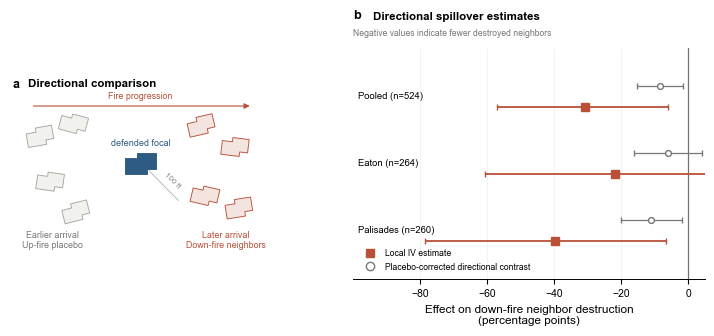

In [10]:
fig = plot_defense_spillover(spillover_figure_results, EXPLORATORY)
print('saved', EXPLORATORY / 'Fig3_defense_spillover.pdf')

### Damage occurrence versus escalation

The directional design is repeated for any recorded damage, total destruction, and destruction conditional on damage, beginning from the same rematched high-exposure population and retaining complete pairs for each outcome.

#### Stage table

The table reports the first stage and directional contrasts for any damage, destruction, and destruction conditional on recorded damage, pooled and separately by fire.

In [11]:
spillover_stages = spillover_stage_table(
    iv_matched, n_boot=N_BOOT, seed=BOOTSTRAP_SEED
)
spillover_stages.to_csv(
    RESULTS / 'table2e_defense_spillover_stages.csv', index=False
)
stage_display = spillover_stages[[
    'outcome', 'sample', 'matched_pairs', 'first_stage',
    'directional_contrast', 'directional_contrast_lo',
    'directional_contrast_hi', 'local_iv', 'local_iv_lo',
    'local_iv_hi',
]].copy()
for column in stage_display.columns[3:]:
    stage_display[column] = 100 * stage_display[column]
display(stage_display.round(1))

,outcome,sample,matched_pairs,first_stage,directional_contrast,directional_contrast_lo,directional_contrast_hi,local_iv,local_iv_lo,local_iv_hi
0,Any damage,Pooled,262,27.5,-7.4,-13.2,-1.8,-27.1,-50.7,-7.2
1,Any damage,Eaton,132,27.3,-5.8,-14.6,2.9,-21.1,-55.7,12.6
2,Any damage,Palisades,130,27.7,-9.1,-16.8,-1.5,-33.0,-69.3,-6.3
3,Destruction,Pooled,262,27.5,-8.5,-15.3,-1.4,-30.8,-56.9,-5.5
4,Destruction,Eaton,132,27.3,-6.0,-16.2,3.9,-21.9,-61.5,15.0
5,Destruction,Palisades,130,27.7,-11.0,-20.1,-2.2,-39.7,-79.2,-8.0
6,Destruction conditional on damage,Pooled,220,26.4,-1.3,-6.9,4.5,-4.8,-26.9,18.6
7,Destruction conditional on damage,Eaton,109,25.7,2.3,-5.4,10.0,9.1,-20.5,47.7
8,Destruction conditional on damage,Palisades,111,27.0,-4.8,-13.4,4.0,-17.7,-51.7,15.8


#### Stage figure

The figure compares the direction-adjusted neighbor contrast and its first-stage-scaled estimate across the three damage outcomes.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/exploratory/ED_defense_spillover_stages.pdf


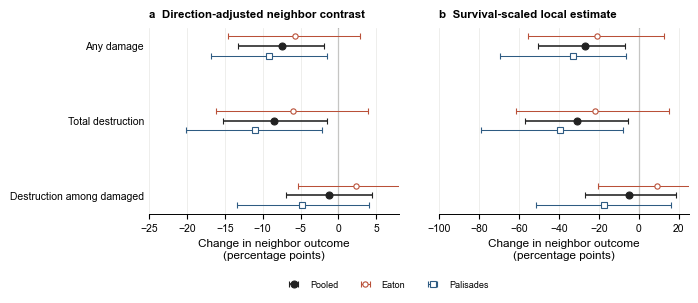

In [12]:
fig = plot_defense_spillover_stages(spillover_stages, EXPLORATORY)
print('saved', EXPLORATORY / 'ED_defense_spillover_stages.pdf')

### Main defense table

The direct matched comparison and down-fire spillover are rendered in one table with pooled, Eaton, and Palisades columns. The spillover population is independently restricted and rematched, so its pairs are not a subset of the direct-effect pairs.

In [13]:
# One main table for the defense section: the matched focal comparison and the
# down-fire spillover in a single grid, with the three samples as columns.
SAMPLES = ['Pooled', 'Eaton', 'Palisades']


def _pp(value, low=None, high=None, decimals=1):
    text = f'{100 * value:.{decimals}f}'
    if low is not None:
        text += f' ({100 * low:.{decimals}f} to {100 * high:.{decimals}f})'
    return text.replace('-', '−')


direct_by_sample = direct.set_index('sample')
spillover_by_sample = spillover.set_index('sample')
outcomes_by_group = outcomes.set_index('group')

defense_rows = [{'Estimand': '**Defended structure, all eligible focals**',
                 **{sample: '' for sample in SAMPLES}}]
defense_rows.append({
    'Estimand': 'Matched pairs',
    **{sample: f'{direct_by_sample.loc[sample, "matched_pairs"]:,.0f}'
       for sample in SAMPLES}})
defense_rows.append({
    'Estimand': 'Survival difference, pp (95% CI)',
    **{sample: (f'{direct_by_sample.loc[sample, "survival_difference_pp"]:.1f} '
                f'({direct_by_sample.loc[sample, "ci_lo"]:.1f} to '
                f'{direct_by_sample.loc[sample, "ci_hi"]:.1f})')
       for sample in SAMPLES}})
for label, column in [('Destroyed, defended versus control, %', 'Destroyed'),
                      ('Partial damage, defended versus control, %', 'Partial'),
                      ('Undamaged, defended versus control, %', 'Undamaged')]:
    defense_rows.append({
        'Estimand': label,
        'Pooled': (f'{outcomes_by_group.loc["Defended", column]:.1f} versus '
                   f'{outcomes_by_group.loc["Matched control", column]:.1f}'),
        'Eaton': '', 'Palisades': ''})

# The spillover population is restricted and rematched, so its pairs are not a
# subset of the pairs above.
eligible_counts = {'Pooled': len(iv_eligible),
                   **{fire.title(): int(count) for fire, count
                      in iv_eligible.fire.value_counts().items()}}
defense_rows.append({
    'Estimand': '**Down-fire neighbors, high-exposure population**',
    **{sample: '' for sample in SAMPLES}})
defense_rows.append({
    'Estimand': 'Eligible focal structures',
    **{sample: f'{eligible_counts.get(sample, float("nan")):,.0f}'
       for sample in SAMPLES}})
defense_rows.append({
    'Estimand': 'Rematched pairs',
    **{sample: f'{spillover_by_sample.loc[sample, "defended_n"]:,.0f}'
       for sample in SAMPLES}})
SPILLOVER_ROWS = [
    ('First stage: focal survival difference, pp', 'first_stage', False),
    ('Down-fire neighbor destruction, pp (95% CI)', 'downfire_contrast', True),
    ('Up-fire placebo, pp (95% CI)', 'upfire_placebo', True),
    ('Difference-in-differences, pp (95% CI)', 'directional_contrast', True),
    ('Local IV per focal structure saved, pp (95% CI)', 'local_iv', True),
]
for label, column, interval in SPILLOVER_ROWS:
    defense_rows.append({
        'Estimand': label,
        **{sample: _pp(spillover_by_sample.loc[sample, column],
                       spillover_by_sample.loc[sample, f'{column}_lo'],
                       spillover_by_sample.loc[sample, f'{column}_hi'])
           if interval else _pp(spillover_by_sample.loc[sample, column])
           for sample in SAMPLES}})
defense_main_table = pd.DataFrame(defense_rows).set_index('Estimand')
defense_main_table.to_csv(RESULTS / 'table2_defense_outcomes.csv')
pooled = spillover_by_sample.loc['Pooled']
legend = (
    'Each defended structure was matched to one undefended structure in the '
    'same fire, without replacement, on a propensity score for pre-arrival '
    'exposure, coupling, destroyed-neighbor count, neighbor count within '
    '500 ft, wind at arrival, arrival time, elevation and vegetation. A '
    'positive survival difference means defended structures survived more '
    'often than their matched controls. The down-fire rows use a separate population, '
    'focal structures with at least 75% of up-fire neighbors destroyed and '
    'rematched within that restriction, so their pairs are not a subset of '
    'those above. The difference-in-differences subtracts the up-fire '
    'contrast, where defense cannot act because those neighbors burned first, '
    'from the down-fire contrast. The local instrumental-variable estimate '
    'divides it by the first stage, giving the reduction in down-fire '
    'destruction per focal structure saved (first-stage '
    f'*F* = {pooled.first_stage_F:.1f}). Intervals resample complete matched '
    'pairs within fire. pp, percentage points.')

lines = ['**Table 2 | Documented structure defense and its down-fire '
         'spillover.**', '',
         '| Estimand | ' + ' | '.join(SAMPLES) + ' |',
         '|---|:--:|:--:|:--:|']
for estimand, row in defense_main_table.iterrows():
    lines.append(f'| {estimand} | ' + ' | '.join(row[SAMPLES]) + ' |')
lines += ['', legend]
defense_main_markdown = '\n'.join(lines)
(RESULTS / 'table2_defense_outcomes.md').write_text(
    defense_main_markdown + '\n', encoding='utf-8')

display(Markdown(defense_main_markdown))
print('saved', RESULTS / 'table2_defense_outcomes.md')

**Table 2 | Documented structure defense and its down-fire spillover.**

| Estimand | Pooled | Eaton | Palisades |
|---|:--:|:--:|:--:|
| **Defended structure, all eligible focals** |  |  |  |
| Matched pairs | 1,154 | 605 | 549 |
| Survival difference, pp (95% CI) | 13.6 (9.6 to 17.7) | 7.4 (1.9 to 12.7) | 20.4 (14.6 to 26.2) |
| Destroyed, defended versus control, % | 39.0 versus 52.6 |  |  |
| Partial damage, defended versus control, % | 25.2 versus 8.1 |  |  |
| Undamaged, defended versus control, % | 35.8 versus 39.3 |  |  |
| **Down-fire neighbors, high-exposure population** |  |  |  |
| Eligible focal structures | 10,663 | 6,227 | 4,436 |
| Rematched pairs | 262 | 132 | 130 |
| First stage: focal survival difference, pp | 27.5 | 27.3 | 27.7 |
| Down-fire neighbor destruction, pp (95% CI) | −10.8 (−16.9 to −4.9) | −9.5 (−17.1 to −1.3) | −12.1 (−21.2 to −3.1) |
| Up-fire placebo, pp (95% CI) | −2.3 (−6.3 to 1.3) | −3.6 (−9.6 to 2.6) | −1.1 (−5.7 to 3.5) |
| Difference-in-differences, pp (95% CI) | −8.5 (−15.2 to −1.5) | −6.0 (−16.2 to 4.1) | −11.0 (−20.0 to −1.9) |
| Local IV per focal structure saved, pp (95% CI) | −30.8 (−57.2 to −6.0) | −21.9 (−60.7 to 17.9) | −39.7 (−78.5 to −6.7) |

Each defended structure was matched to one undefended structure in the same fire, without replacement, on a propensity score for pre-arrival exposure, coupling, destroyed-neighbor count, neighbor count within 500 ft, wind at arrival, arrival time, elevation and vegetation. A positive survival difference means defended structures survived more often than their matched controls. The down-fire rows use a separate population, focal structures with at least 75% of up-fire neighbors destroyed and rematched within that restriction, so their pairs are not a subset of those above. The difference-in-differences subtracts the up-fire contrast, where defense cannot act because those neighbors burned first, from the down-fire contrast. The local instrumental-variable estimate divides it by the first stage, giving the reduction in down-fire destruction per focal structure saved (first-stage *F* = 54.6). Intervals resample complete matched pairs within fire. pp, percentage points.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/defense/table2_defense_outcomes.md


### Sensitivity to design choices

The upstream-destruction threshold, arrival window, neighbor radius, realized up-fire coupling restriction, spatial resampling, and defense isolation definition are varied while rebuilding or rematching the OpenView directional population as required.

In [14]:
from src.analysis.defense_sensitivity import (
    add_pair_spatial_context, design_sensitivity,
    spatial_and_isolation_table, threshold_sensitivity,
    upfire_exposure_quantile_sensitivity,
)

# Each specification repeats the whole pipeline: restrict, rematch, estimate.
threshold = threshold_sensitivity(
    focal, thresholds=(.60, .70, .75, .80, .90),
    n_boot=SENSITIVITY_BOOT, seed=SENSITIVITY_SEED)
threshold.to_csv(RESULTS / 'tableS_defense_threshold_sensitivity.csv',
                 index=False)
upfire_exposure = upfire_exposure_quantile_sensitivity(
    focal, quantiles=(.75, .50), n_boot=SENSITIVITY_BOOT,
    seed=SENSITIVITY_SEED + 100)
upfire_exposure.to_csv(
    RESULTS / 'tableS_defense_upfire_exposure_sensitivity.csv',
    index=False)
def _openview_focal_builder(*, max_abs_dt_hours, neighbor_radius_m):
    return build_openview_focal_table(
        PROJECT_ROOT, OPENVIEW_3D_RUN, ANALYSIS_PATH, BUILDING_CACHE, EDGE_CACHE,
        max_abs_dt_hours=max_abs_dt_hours,
        neighbor_radius_m=neighbor_radius_m,
        rebuild_edges=False,
    )


design = design_sensitivity(
    PROJECT_ROOT, focal, DESIGN_CACHE,
    n_boot=SENSITIVITY_BOOT, seed=SENSITIVITY_SEED,
    focal_builder=_openview_focal_builder)
design.to_csv(RESULTS / 'tableS_defense_design_sensitivity.csv', index=False)

# Spatial isolation is evaluated after the primary high-exposure matching.
# A defended focal is isolated when its nearest other documented defended
# focal in the eligible focal population is more than 150 m away.
isolation_context = add_pair_spatial_context(
    PROJECT_ROOT, focal, iv_matched, block_m=250, isolation_m=150)
isolation = spatial_and_isolation_table(
    isolation_context, n_boot=SENSITIVITY_BOOT,
    seed=SENSITIVITY_SEED)
isolation.to_csv(
    RESULTS / 'tableS_defense_spatial_isolation.csv', index=False)

# One table over every design choice, so the range quoted in the text is
# reproducible from a single output rather than assembled from two files.
PRIMARY_LABEL = 'Primary: 75% threshold, ±3 h, 100 ft'
sensitivity_rows = []
for _, row in design.iterrows():
    primary = row.design.startswith('Primary')
    sensitivity_rows.append({
        'block': 'Primary specification' if primary else (
            'Arrival window' if 'window' in row.design
            else 'Neighbor radius'),
        'Specification': PRIMARY_LABEL if primary else row.design.split(': ')[1],
        'is_primary': primary, **row.to_dict()})
for _, row in threshold.iterrows():
    if np.isclose(row.upstream_destroyed_threshold, .75):
        continue  # the primary specification, already listed
    sensitivity_rows.append({
        'block': 'Upstream-destruction threshold',
        'Specification':
            f'{100 * row.upstream_destroyed_threshold:.0f}% of up-fire '
            'neighbors destroyed',
        'is_primary': False, **row.to_dict()})
for _, row in upfire_exposure.iterrows():
    sensitivity_rows.append({
        'block': 'Realized up-fire coupling',
        'Specification':
            f'Top {100 * (1 - row.upfire_exposure_quantile):.0f}% of '
            r'$F^*_{up}$ within fire',
        'is_primary': False, **row.to_dict()})
defense_sensitivity_table = pd.DataFrame(sensitivity_rows)
defense_sensitivity_table['directional_pp'] = (
    100 * defense_sensitivity_table.directional_contrast)
defense_sensitivity_table.to_csv(
    RESULTS / 'tableS_defense_sensitivity_summary.csv', index=False)

BLOCK_ORDER = ['Primary specification', 'Arrival window', 'Neighbor radius',
               'Upstream-destruction threshold',
               'Realized up-fire coupling']
COLUMNS = [('eligible_n', 'Eligible focal structures', '{:,.0f}'),
           ('pairs', 'Rematched pairs', '{:,.0f}'),
           ('max_abs_smd', 'Largest absolute SMD', '{:.3f}'),
           ('first_stage', 'First stage (pp)', '{:.1f}')]
lines = ['**Supplementary Table | Sensitivity of the down-fire spillover '
         'estimate to design choices.**', '',
         '| Specification | ' + ' | '.join(label for _, label, _ in COLUMNS)
         + ' | Difference-in-differences, pp (95% CI) |',
         '|---|' + '|'.join([':--:'] * (len(COLUMNS) + 1)) + '|']
for block in BLOCK_ORDER:
    rows = defense_sensitivity_table[defense_sensitivity_table.block.eq(block)]
    if rows.empty:
        continue
    if block != 'Primary specification':
        lines.append(f'| **{block}** | ' + ' | '.join([''] * (len(COLUMNS) + 1))
                     + ' |')
    for _, row in rows.iterrows():
        contrast = (f'{100 * row.directional_contrast:.1f} '
                    f'({100 * row.directional_lo:.1f} to '
                    f'{100 * row.directional_hi:.1f})').replace('-', '−')
        cells = [fmt.format(row[key] * (100 if key == 'first_stage' else 1))
                 for key, _, fmt in COLUMNS]
        lines.append(f'| {row.Specification} | ' + ' | '.join(cells)
                     + f' | {contrast} |')

alternatives = defense_sensitivity_table[~defense_sensitivity_table.is_primary]
contrasts = 100 * alternatives.directional_contrast.abs()
protective = alternatives.directional_hi.lt(0)
lines += ['', (
    'Each row repeats the eligibility, matching and estimation pipeline with '
    'one design choice altered and the others held at the primary '
    'specification (75% up-fire destruction threshold, ±3 h arrival window, '
    '100 ft neighbor radius). The realized up-fire coupling rows instead '
    'replace the 75% neighbor-outcome restriction with fire-specific '
    '$F^*_{up}$ quantile cutoffs. The difference-in-differences is the down-fire '
    'minus up-fire contrast between defended structures and matched controls; '
    f'intervals are {SENSITIVITY_BOOT:,} bootstrap resamples of complete pairs '
    'within fire. SMD, standardized mean difference after matching; first '
    'stage, matched difference in focal-structure survival; pp, percentage '
    'points.'), '',
    '**Supplementary Table | Spatial dependence and defense isolation.**', '',
    '| Analysis | Matched pairs | Spatial blocks | First stage (pp) | '
    'Difference-in-differences, pp (95% CI) | Local IV, pp (95% CI) |',
    '|---|:--:|:--:|:--:|:--:|:--:|']
for _, row in isolation[~isolation.analysis.str.contains(
        'matched-pair')].iterrows():
    did = (f'{100 * row.directional_contrast:.1f} '
           f'({100 * row.directional_lo:.1f} to '
           f'{100 * row.directional_hi:.1f})').replace('-', '−')
    local_iv = (f'{100 * row.local_iv:.1f} '
                f'({100 * row.local_iv_lo:.1f} to '
                f'{100 * row.local_iv_hi:.1f})').replace('-', '−')
    lines.append(
        f'| {row.analysis} | {row.pairs:,.0f} | '
        f'{row.spatial_blocks:,.0f} | {100 * row.first_stage:.1f} | '
        f'{did} | {local_iv} |')
isolated_pairs = int(isolation.loc[
    isolation.analysis.str.contains('Isolated'), 'pairs'].iloc[0])
lines += ['', (
    'The primary spillover specification re-estimated with 250-m spatial '
    'block resampling, and split by whether the defended focal structure '
    'stands apart from other documented defense. A focal is isolated when the '
    'nearest other documented defended focal in the eligible population is '
    'more than 150 m (492 ft) away; its matched control is retained. The '
    'isolated rows test whether the neighbor contrast reflects a jointly '
    'defended cluster rather than the focal action, but rest on '
    f'{isolated_pairs} pairs and are read as directional rather than as a '
    'precise effect size. Blocks resample within fire, retaining complete '
    'pairs. pp, percentage points.')]
defense_sensitivity_markdown = '\n'.join(lines)
(RESULTS / 'tableS_defense_sensitivity_summary.md').write_text(
    defense_sensitivity_markdown + '\n', encoding='utf-8')

display(Markdown(defense_sensitivity_markdown))
print('across {} alternatives: {:.1f} to {:.1f} pp, median {:.1f}, excluding zero in {} of {}'.format(
    len(alternatives), contrasts.min(), contrasts.max(),
    contrasts.median(), int(protective.sum()), len(protective)))
print('saved', RESULTS / 'tableS_defense_sensitivity_summary.md')

/Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/src/analysis/defense.py:633: RuntimeWarning: divide by zero encountered in divide
  "local_iv": directional / first_stage,
/Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/src/analysis/defense.py:633: RuntimeWarning: divide by zero encountered in divide
  "local_iv": directional / first_stage,
/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


**Supplementary Table | Sensitivity of the down-fire spillover estimate to design choices.**

| Specification | Eligible focal structures | Rematched pairs | Largest absolute SMD | First stage (pp) | Difference-in-differences, pp (95% CI) |
|---|:--:|:--:|:--:|:--:|:--:|
| Primary: 75% threshold, ±3 h, 100 ft | 10,663 | 262 | 0.096 | 27.5 | −8.5 (−15.5 to −1.9) |
| **Arrival window** |  |  |  |  |  |
| 1.5 h | 10,769 | 263 | 0.072 | 34.2 | −13.2 (−19.7 to −7.2) |
| 6 h | 10,680 | 261 | 0.057 | 27.2 | −12.0 (−18.3 to −5.8) |
| **Neighbor radius** |  |  |  |  |  |
| 50 ft | 8,694 | 132 | 0.178 | 40.2 | −5.5 (−15.3 to 4.3) |
| 150 ft | 11,366 | 324 | 0.144 | 29.0 | −8.7 (−14.3 to −3.3) |
| **Upstream-destruction threshold** |  |  |  |  |  |
| 60% of up-fire neighbors destroyed | 12,772 | 327 | 0.116 | 25.4 | −9.1 (−14.9 to −2.9) |
| 70% of up-fire neighbors destroyed | 11,321 | 281 | 0.056 | 26.7 | −8.5 (−14.7 to −2.2) |
| 80% of up-fire neighbors destroyed | 9,713 | 227 | 0.102 | 25.6 | −15.3 (−22.2 to −8.7) |
| 90% of up-fire neighbors destroyed | 7,000 | 143 | 0.093 | 24.5 | −6.1 (−13.9 to 0.9) |
| **Realized up-fire coupling** |  |  |  |  |  |
| Top 25% of $F^*_{up}$ within fire | 5,570 | 143 | 0.098 | 14.7 | −0.1 (−8.8 to 7.7) |
| Top 50% of $F^*_{up}$ within fire | 11,270 | 299 | 0.135 | 22.1 | −3.3 (−9.5 to 3.0) |

Each row repeats the eligibility, matching and estimation pipeline with one design choice altered and the others held at the primary specification (75% up-fire destruction threshold, ±3 h arrival window, 100 ft neighbor radius). The realized up-fire coupling rows instead replace the 75% neighbor-outcome restriction with fire-specific $F^*_{up}$ quantile cutoffs. The difference-in-differences is the down-fire minus up-fire contrast between defended structures and matched controls; intervals are 1,000 bootstrap resamples of complete pairs within fire. SMD, standardized mean difference after matching; first stage, matched difference in focal-structure survival; pp, percentage points.

**Supplementary Table | Spatial dependence and defense isolation.**

| Analysis | Matched pairs | Spatial blocks | First stage (pp) | Difference-in-differences, pp (95% CI) | Local IV, pp (95% CI) |
|---|:--:|:--:|:--:|:--:|:--:|
| Primary: 250-m block bootstrap | 262 | 108 | 27.5 | −8.5 (−15.3 to −1.8) | −30.8 (−60.0 to −7.0) |
| Isolated defense (>150 m) | 21 | 21 | 81.0 | −35.3 (−62.5 to −10.6) | −43.6 (−78.4 to −13.4) |
| Clustered defense (<=150 m) | 241 | 90 | 22.8 | −6.1 (−13.6 to 1.3) | −26.9 (−62.2 to 6.8) |

The primary spillover specification re-estimated with 250-m spatial block resampling, and split by whether the defended focal structure stands apart from other documented defense. A focal is isolated when the nearest other documented defended focal in the eligible population is more than 150 m (492 ft) away; its matched control is retained. The isolated rows test whether the neighbor contrast reflects a jointly defended cluster rather than the focal action, but rest on 21 pairs and are read as directional rather than as a precise effect size. Blocks resample within fire, retaining complete pairs. pp, percentage points.

across 10 alternatives: 0.1 to 15.3 pp, median 8.6, excluding zero in 6 of 10
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/defense/tableS_defense_sensitivity_summary.md


**Stage interpretation.** The stage analysis distinguishes whether the directional association is concentrated in preventing any recorded damage, preventing complete destruction, or preventing escalation among already-damaged neighbors. Numerical estimates are generated by the preceding cells from the updated OpenView graph.

## Emitter-removal mechanism

Each focal structure’s OpenView coupling is decomposed into potential up-fire and down-fire coupling, the components directed toward defended neighbors, and the component directed toward neighbors ultimately destroyed. The second specification adds the destroyed share of up-fire coupling. Because that share is post-treatment, this remains a descriptive mechanism diagnostic.

In [15]:
view_frame = build_openview_view_decomposition(
    PROJECT_ROOT, OPENVIEW_3D_RUN, ANALYSIS_PATH, BUILDING_CACHE, EDGE_CACHE,
    focal,
)
mechanism = mechanism_table(view_frame)
mechanism.to_csv(RESULTS / 'table2d_defense_mechanism.csv', index=False)

# Reader-facing supplementary table for the emitter-removal diagnostic.
model_labels = {
    'Potential coupling only': 'Adjusted for potential coupling',
    '+ destroyed share': '+ destroyed fraction of up-fire coupling',
}
term_labels = {
    'Defended component of up-fire view':
        'Defended up-fire (earlier-arriving) coupling',
    'Defended down-fire view (placebo)':
        'Defended down-fire (later-arriving) coupling control',
    'Destroyed fraction of up-fire view':
        'Destroyed fraction of up-fire coupling',
}
mechanism_supplement = mechanism.assign(
    Specification=mechanism.model.map(model_labels),
    Predictor=mechanism.term.map(term_labels),
).rename(columns={
    'ame_pp_per_sd': 'Average marginal effect (pp per SD)',
    'p_value': 'P value', 'n': 'Structures',
})[[
    'Specification', 'Predictor',
    'Average marginal effect (pp per SD)', 'P value', 'Structures',
]]
mechanism_supplement.to_csv(
    RESULTS / 'tableS_defense_emitter_removal.csv', index=False)

def _format_p(value):
    return '<0.001' if value < .001 else f'{value:.3f}'

lines = [
    '**Supplementary Table | Coupling-weighted defense and focal-structure destruction.**',
    '',
    '| Model | Predictor | Average marginal effect, pp per s.d. | *P* | Structures |',
    '|---|---|---:|---:|---:|',
]
for _, row in mechanism_supplement.iterrows():
    lines.append(
        f'| {row["Specification"]} | {row["Predictor"]} | '
        f'{row["Average marginal effect (pp per SD)"]:+.2f} | '
        f'{_format_p(row["P value"])} | {row["Structures"]:,.0f} |')
lines += ['', (
    'Average marginal effects are changes in predicted destruction for a '
    'one-standard-deviation increase in the indicated term. Defended-view '
    'terms are log(1 + summed geometric coupling) to documented defended '
    'structures. The common adjustment set comprises focal-structure defense, '
    'potential up- and down-fire coupling, total potential exposure, local '
    'neighbor density within 500 ft, wind speed at arrival, reconstructed '
    'arrival time, elevation, pre-fire NDVI and a fire indicator. The second '
    'specification additionally adjusts for the destroyed fraction of the '
    'up-fire coupling. This is not Supplementary Model 5: that construction '
    'model instead adjusts for realized F*, roof material, building vintage, '
    'distance into the built environment, connected-neighbor count, NDVI, '
    'fire and focal defense. The down-fire term '
    'is a temporal control, and the destroyed fraction is a post-treatment '
    'variable; these estimates are therefore descriptive. Two-sided P '
    'values are coefficient Wald tests from the fitted logistic models. '
    'pp, percentage points; s.d., standard deviation.')]
mechanism_supplement_markdown = '\n'.join(lines)
(RESULTS / 'tableS_defense_emitter_removal.md').write_text(
    mechanism_supplement_markdown + '\n', encoding='utf-8')
display(Markdown(mechanism_supplement_markdown))

# Complete fitted-model output for reviewer inspection.
mechanism_full = mechanism_regression_table(view_frame)
mechanism_full.to_csv(
    RESULTS / 'tableS_defense_emitter_removal_full_regression.csv',
    index=False)
full_term_labels = {
    'Intercept': 'Intercept',
    'defended': 'Focal structure documented defense',
    'l_up_defended': 'Log defended earlier-arrival coupling',
    'l_down_defended': 'Log defended later-arrival coupling',
    'l_up_potential': 'Log potential earlier-arrival coupling',
    'l_down_potential': 'Log potential later-arrival coupling',
    'l_F_total_wmean': 'Log total potential structural exposure',
    'l_n_neighbors_500ft': 'Log connected neighbors within 500 ft',
    'wind_speed_arrival_mph': 'Wind speed at arrival (mph)',
    'arrival': 'Reconstructed arrival time (h)',
    'elevation': 'Elevation (m)',
    'ndvi_mean': 'Pre-fire NDVI',
    'fire_b': 'Fire: Palisades',
    'destroyed_up_share': 'Destroyed fraction of earlier-arrival coupling',
}
full_model_order = ['Potential coupling only', '+ destroyed share']
full_model_names = {
    'Potential coupling only': '(1) Potential coupling',
    '+ destroyed share': '(2) + destroyed fraction',
}
full_term_order = list(full_term_labels)
def _coef_se(row):
    return f'{row.coefficient:.3f} ({row.standard_error:.3f})'
full_lines = [
    '**Supplementary Table | Full logistic regressions for the emitter-removal diagnostic.**',
    '',
    '| Predictor | (1) Coefficient (s.e.) | *P* | (2) Coefficient (s.e.) | *P* |',
    '|---|---:|---:|---:|---:|',
]
for term in full_term_order:
    cells = []
    for model_name in full_model_order:
        hit = mechanism_full[(mechanism_full.model == model_name) &
                             (mechanism_full.term == term)]
        if hit.empty:
            cells.extend(['—', '—'])
        else:
            row = hit.iloc[0]
            cells.extend([_coef_se(row), _format_p(row.p_value)])
    full_lines.append(
        f'| {full_term_labels[term]} | ' + ' | '.join(cells) + ' |')
full_lines += ['', '| Model statistic | (1) |  | (2) |  |',
               '|---|---:|---:|---:|---:|']
for label, key, formatter in [
    ('Structures', 'n', lambda value: f'{value:,.0f}'),
    ('Destroyed structures', 'events', lambda value: f'{value:,.0f}'),
    ('Parameters', 'parameters', lambda value: f'{value:,.0f}'),
    ('Log likelihood', 'log_likelihood', lambda value: f'{value:.1f}'),
    ('AIC', 'aic', lambda value: f'{value:.1f}'),
    ('McFadden pseudo-R²', 'mcfadden_pseudo_r2', lambda value: f'{value:.3f}'),
]:
    values = []
    for model_name in full_model_order:
        row = mechanism_full[mechanism_full.model == model_name].iloc[0]
        values.extend([formatter(row[key]), ''])
    full_lines.append(f'| {label} | ' + ' | '.join(values) + ' |')
full_lines += ['', (
    'Logistic regressions of focal-structure destruction. Model 1 includes '
    'the common adjustment set; Model 2 additionally includes the destroyed '
    'fraction of earlier-arrival coupling. Coupling and neighbor-count terms '
    'are transformed as log(1 + x). Coefficients are log-odds estimates; '
    'model-based standard errors are shown in parentheses. Two-sided P values '
    'are coefficient Wald tests. The destroyed fraction is a post-treatment '
    'quantity, so Model 2 is a descriptive mechanism diagnostic rather than '
    'a causal mediation model.')]
mechanism_full_markdown = '\n'.join(full_lines)
(RESULTS / 'tableS_defense_emitter_removal_full_regression.md').write_text(
    mechanism_full_markdown + '\n', encoding='utf-8')
display(Markdown(mechanism_full_markdown))

**Supplementary Table | Coupling-weighted defense and focal-structure destruction.**

| Model | Predictor | Average marginal effect, pp per s.d. | *P* | Structures |
|---|---|---:|---:|---:|
| Adjusted for potential coupling | Defended up-fire (earlier-arriving) coupling | -0.78 | 0.009 | 24,317 |
| Adjusted for potential coupling | Defended down-fire (later-arriving) coupling control | -0.49 | 0.106 | 24,317 |
| + destroyed fraction of up-fire coupling | Defended up-fire (earlier-arriving) coupling | +0.79 | <0.001 | 24,317 |
| + destroyed fraction of up-fire coupling | Defended down-fire (later-arriving) coupling control | -0.16 | 0.446 | 24,317 |
| + destroyed fraction of up-fire coupling | Destroyed fraction of up-fire coupling | +18.65 | <0.001 | 24,317 |

Average marginal effects are changes in predicted destruction for a one-standard-deviation increase in the indicated term. Defended-view terms are log(1 + summed geometric coupling) to documented defended structures. The common adjustment set comprises focal-structure defense, potential up- and down-fire coupling, total potential exposure, local neighbor density within 500 ft, wind speed at arrival, reconstructed arrival time, elevation, pre-fire NDVI and a fire indicator. The second specification additionally adjusts for the destroyed fraction of the up-fire coupling. This is not Supplementary Model 5: that construction model instead adjusts for realized F*, roof material, building vintage, distance into the built environment, connected-neighbor count, NDVI, fire and focal defense. The down-fire term is a temporal control, and the destroyed fraction is a post-treatment variable; these estimates are therefore descriptive. Two-sided P values are coefficient Wald tests from the fitted logistic models. pp, percentage points; s.d., standard deviation.

**Supplementary Table | Full logistic regressions for the emitter-removal diagnostic.**

| Predictor | (1) Coefficient (s.e.) | *P* | (2) Coefficient (s.e.) | *P* |
|---|---:|---:|---:|---:|
| Intercept | -5.729 (0.245) | <0.001 | -4.314 (0.308) | <0.001 |
| Focal structure documented defense | -0.903 (0.074) | <0.001 | -1.146 (0.091) | <0.001 |
| Log defended earlier-arrival coupling | -2.229 (0.858) | 0.009 | 3.974 (1.095) | <0.001 |
| Log defended later-arrival coupling | -1.357 (0.841) | 0.106 | -0.796 (1.046) | 0.446 |
| Log potential earlier-arrival coupling | 9.250 (0.443) | <0.001 | 4.973 (0.554) | <0.001 |
| Log potential later-arrival coupling | 9.159 (0.442) | <0.001 | 5.554 (0.550) | <0.001 |
| Log total potential structural exposure | -7.513 (0.445) | <0.001 | -3.816 (0.543) | <0.001 |
| Log connected neighbors within 500 ft | 0.979 (0.034) | <0.001 | 0.324 (0.044) | <0.001 |
| Wind speed at arrival (mph) | 0.075 (0.006) | <0.001 | 0.044 (0.008) | <0.001 |
| Reconstructed arrival time (h) | -0.132 (0.004) | <0.001 | -0.053 (0.004) | <0.001 |
| Elevation (m) | 0.003 (0.000) | <0.001 | 0.001 (0.000) | <0.001 |
| Pre-fire NDVI | 1.945 (0.137) | <0.001 | 1.068 (0.178) | <0.001 |
| Fire: Palisades | 3.618 (0.087) | <0.001 | 1.390 (0.103) | <0.001 |
| Destroyed fraction of earlier-arrival coupling | — | — | 4.008 (0.048) | <0.001 |

| Model statistic | (1) |  | (2) |  |
|---|---:|---:|---:|---:|
| Structures | 24,317 |  | 24,317 |  |
| Destroyed structures | 14,480 |  | 14,480 |  |
| Parameters | 13 |  | 14 |  |
| Log likelihood | -13945.2 |  | -9052.3 |  |
| AIC | 27916.5 |  | 18132.6 |  |
| McFadden pseudo-R² | 0.150 |  | 0.448 |  |

Logistic regressions of focal-structure destruction. Model 1 includes the common adjustment set; Model 2 additionally includes the destroyed fraction of earlier-arrival coupling. Coupling and neighbor-count terms are transformed as log(1 + x). Coefficients are log-odds estimates; model-based standard errors are shown in parentheses. Two-sided P values are coefficient Wald tests. The destroyed fraction is a post-treatment quantity, so Model 2 is a descriptive mechanism diagnostic rather than a causal mediation model.

### Partial damage within the view decomposition

The same OpenView view decomposition is fitted separately for any damage versus undamaged and for partial damage versus destruction among damaged structures.

In [16]:
mechanism_partial = mechanism_partial_damage_table(view_frame)
mechanism_partial.to_csv(
    RESULTS / 'table2e_defense_mechanism_partial_damage.csv', index=False)
display(mechanism_partial.round(3))

,stage,model,term,ame_pp_per_sd,coefficient,p_value,n
0,Any damage vs undamaged,Potential coupling only,Defended component of up-fire view,-1.130,-3.524,0.000,24317
1,Any damage vs undamaged,Potential coupling only,Defended down-fire view (control),-0.826,-2.491,0.004,24317
2,Any damage vs undamaged,+ destroyed share,Defended component of up-fire view,0.381,2.083,0.059,24317
3,Any damage vs undamaged,+ destroyed share,Defended down-fire view (control),-0.458,-2.409,0.027,24317
4,Any damage vs undamaged,+ destroyed share,Destroyed fraction of up-fire view,17.951,4.157,0.000,24317
5,"Partial vs destroyed, among damaged",Potential coupling only,Defended component of up-fire view,-0.147,-0.972,0.490,16128
6,"Partial vs destroyed, among damaged",Potential coupling only,Defended down-fire view (control),-0.119,-0.753,0.578,16128
7,"Partial vs destroyed, among damaged",+ destroyed share,Defended component of up-fire view,-0.548,-4.109,0.007,16128
8,"Partial vs destroyed, among damaged",+ destroyed share,Defended down-fire view (control),-0.138,-0.977,0.494,16128
9,"Partial vs destroyed, among damaged",+ destroyed share,Destroyed fraction of up-fire view,-4.522,-2.389,0.000,16128
